In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath(".."))
from Filters.kalman import KalmanFilter
from Filters.ukf import UnscentedKalmanFilter
from Filters.particle import ParticleFilter
from Filters.ukf_pf import UKF_PF
from Models.lokta_volterra import LotkaVolterraSSM

# Code

In [32]:
import numpy as np
from scipy.stats import skew, kurtosis, wasserstein_distance
from scipy.stats import multivariate_normal
import ot
from scipy.spatial.distance import cdist
from tqdm import tqdm

class SSMDistributionAnalyzer:

    def __init__(self, model, T, N=10000, bins=50, random_seed=42):

        self.model = model
        self.T = T
        self.N = N
        self.bins = bins
        self.random_seed = random_seed

        if random_seed is not None:
            np.random.seed(random_seed)

        self.d = model.d
        self.m = model.m

        self.X_samples = None
        self.Y_samples = None


    # ----------------------------
    # Shannon entropy
    # ----------------------------

    @staticmethod
    def shannon_entropy(p):

        p = p[p > 0]

        return -np.sum(p * np.log(p))


    # ----------------------------
    # Monte Carlo simulation
    # ----------------------------

    def simulate(self):

        X_samples = np.zeros((self.N, self.T + 1, self.d))
        Y_samples = np.zeros((self.N, self.T, self.m))

        i = 0

        with tqdm(total=self.N, desc="Simulating data", unit="sample") as pbar:

            while i < self.N:

                X, Y = self.model.simulate(self.T)

                if np.isfinite(X).all() and np.isfinite(Y).all():

                    X_samples[i] = X
                    Y_samples[i] = Y

                    i += 1
                    pbar.update(1)

        self.X_samples = X_samples
        self.Y_samples = Y_samples


    # ----------------------------
    # Statistics computation
    # ----------------------------
    def compute_statistics(self, samples):

        samples = np.asarray(samples)

        n, dim = samples.shape

        mean = np.mean(samples, axis=0)
        cov = np.cov(samples, rowvar=False)
        var = np.diag(cov)
        cov = cov + 1e-8 * np.eye(dim)

        skewness = skew(samples, axis=0)
        kurt = kurtosis(samples, axis=0)

        # Histogram density

        hist, edges = np.histogramdd(
            samples,
            bins=self.bins,
            density=True
        )

        p = hist / np.sum(hist)

        entropy = self.shannon_entropy(p.flatten())

        # Gaussian reference

        gauss = multivariate_normal(
            mean=mean,
            cov=np.atleast_2d(cov),
            allow_singular=True
        )

        centers = [
            0.5 * (e[:-1] + e[1:])
            for e in edges
        ]

        mesh = np.meshgrid(*centers, indexing="ij")

        points = np.stack([m.flatten() for m in mesh], axis=-1)

        q = gauss.pdf(points)

        q = q.reshape(hist.shape)

        q = q / np.sum(q)

        kl = np.sum(
            p.flatten()
            * (np.log(p.flatten() + 1e-12) - np.log(q.flatten() + 1e-12))
        )

        # Wasserstein distances
        try:
            # Gaussian moment-matching distribution
            gaussian_samples = np.random.multivariate_normal(
                mean,
                np.atleast_2d(cov),
                size=2*n
            )
            # weights
            a = np.ones(n) / n
            b = np.ones(2*n) / (2*n)
            # ---------- W1 ----------
            M1 = cdist(samples, gaussian_samples, metric="euclidean")
            W1 = ot.sinkhorn2(a, b, M1, reg=1e-1)
            # ---------- W2 ----------
            M2 = cdist(samples, gaussian_samples, metric="sqeuclidean")
            W2 = np.sqrt(
                ot.sinkhorn2(a, b, M2, reg=1e-1)
            )

        except Exception:

            W1 = np.nan
            W2 = np.nan

        return {
            "mean": mean,
            "variance": var,
            "skewness": skewness,
            "kurtosis": kurt,
            "covariance": cov,
            "entropy": entropy,
            "KL_gaussian": kl,
            "wasserstein_W1": W1,
            "wasserstein_W2": W2,
            "histogram": hist,
            "bin_edges": edges
        }


    # Mutual information
    def compute_mutual_information(self):

        mi_list = []

        for t in range(self.T):

            x = self.X_samples[:, t, 0]
            y = self.Y_samples[:, t, 0]

            joint_hist, x_edges, y_edges = np.histogram2d(
                x,
                y,
                bins=self.bins,
                density=True
            )

            pxy = joint_hist / np.sum(joint_hist)

            px = np.sum(pxy, axis=1)
            py = np.sum(pxy, axis=0)

            mi = 0.0

            for i in range(len(px)):
                for j in range(len(py)):

                    if pxy[i, j] > 0 and px[i] > 0 and py[j] > 0:

                        mi += pxy[i, j] * np.log(pxy[i, j] / (px[i] * py[j]))

            mi_list.append(mi)

        return mi_list

    # Main analysis
    def analyze(self):

        if self.X_samples is None:
            self.simulate()

        results = {
            "states": [],
            "observations": [],
            "mutual_information": []
        }

        # States
        for t in tqdm(range(self.T + 1), desc="Analyzing states", unit="time step"):
            samples = self.X_samples[:, t, :]
            stats = self.compute_statistics(samples)
            results["states"].append(stats)

        # Observations
        for t in tqdm(range(self.T), desc="Analyzing observations", unit="time step"):
            samples = self.Y_samples[:, t, :]
            stats = self.compute_statistics(samples)
            results["observations"].append(stats)

        # Mutual information
        results["mutual_information"] = self.compute_mutual_information()

        return results
    
    # Visualization
    def plot_wasserstein(self, results):

        W1_states = [s["wasserstein_W1"] for s in results["states"]]
        W2_states = [s["wasserstein_W2"] for s in results["states"]]

        W1_obs = [s["wasserstein_W1"] for s in results["observations"]]
        W2_obs = [s["wasserstein_W2"] for s in results["observations"]]

        plt.figure(figsize=(10,5))

        plt.plot(W1_states, label="W1 states")
        plt.plot(W2_states, label="W2 states")

        plt.plot(W1_obs, "--", label="W1 observations")
        plt.plot(W2_obs, "--", label="W2 observations")

        plt.xlabel("time")
        plt.ylabel("Wasserstein distance")

        plt.title("Distributional deviation from Gaussian approximation")

        plt.legend()
        plt.grid(True)

        plt.show()

    def plot_gaussianity(self, results):
        skew_states = np.array([s["skewness"] for s in results["states"]])
        kurt_states = np.array([s["kurtosis"] for s in results["states"]])

        plt.figure(figsize=(10,5))

        for i in range(skew_states.shape[1]):
            plt.plot(skew_states[:,i], label=f"skew state {i}")

        for i in range(kurt_states.shape[1]):
            plt.plot(kurt_states[:,i], "--", label=f"kurt state {i}")

        plt.axhline(0, color="black", linewidth=1)

        plt.title("Gaussianity diagnostics")
        plt.xlabel("time")

        plt.legend()
        plt.grid(True)

        plt.show()
    
    def plot_entropy(self, results):

        entropy_states = [s["entropy"] for s in results["states"]]
        entropy_obs = [s["entropy"] for s in results["observations"]]

        plt.figure(figsize=(10,5))

        plt.plot(entropy_states, label="states")
        plt.plot(entropy_obs, label="observations")

        plt.xlabel("time")
        plt.ylabel("Shannon entropy")

        plt.title("Entropy evolution")

        plt.legend()
        plt.grid(True)

        plt.show()

    def plot_mutual_information(self, results):

        mi = results["mutual_information"]

        plt.figure(figsize=(10,5))

        plt.plot(mi)

        plt.xlabel("time")
        plt.ylabel("Mutual information")

        plt.title("I(X_t ; Y_t)")

        plt.grid(True)

        plt.show()



    def plot_density_heatmap(self, source="states", dim=0, bins=80):

        """
        Temporal density heatmap for states or observations.

        Parameters
        ----------
        source : {"states","observations"}
            Which variable to visualize.

        dim : int
            Dimension to visualize.

        bins : int
            Histogram bins.
        """

        if source == "states":
            data = self.X_samples[:, :, dim]
        elif source == "observations":
            data = self.Y_samples[:, :, dim]
        else:
            raise ValueError("source must be 'states' or 'observations'")

        T = data.shape[1]

        all_values = data.flatten()
        hist_range = (all_values.min(), all_values.max())

        heatmap = []

        for t in range(T):

            hist, edges = np.histogram(
                data[:, t],
                bins=bins,
                range=hist_range,
                density=True
            )

            heatmap.append(hist)

        heatmap = np.array(heatmap).T

        plt.figure(figsize=(10,6))

        plt.imshow(
            heatmap,
            aspect="auto",
            origin="lower",
            extent=[0, T, hist_range[0], hist_range[1]],
            cmap="Blues"
        )

        plt.colorbar(label="density")

        plt.xlabel("time")

        if source == "states":
            plt.ylabel(f"state dimension {dim}")
        else:
            plt.ylabel(f"observation dimension {dim}")

        plt.title(f"Temporal density heatmap ({source})")

        plt.show()

    def plot_snapshot_distribution(self, t, source="states", dims=(0,), bins=40):
        """
        Plot distribution snapshot at fixed time.

        Parameters
        ----------
        t : int
            Time index.

        source : {"states","observations"}
            Variable to visualize.

        dims : tuple
            Dimensions to plot.

        bins : int
            Histogram bins.
        """

        if source == "states":
            data = self.X_samples[:, t, :]
            label = "state"
        elif source == "observations":
            data = self.Y_samples[:, t, :]
            label = "observation"
        else:
            raise ValueError("source must be 'states' or 'observations'")

        dims = tuple(dims)

        if len(dims) == 1:

            d = dims[0]
            values = data[:, d]

            plt.figure(figsize=(6,4))

            plt.hist(values, bins=bins, density=True, alpha=0.7)

            plt.xlabel(f"{label} dimension {d}")
            plt.ylabel("density")
            plt.title(f"{label} distribution at time t={t}")

            plt.grid(True)
            plt.show()

        elif len(dims) == 2:

            d1, d2 = dims

            x = data[:, d1]
            y = data[:, d2]

            plt.figure(figsize=(6,5))

            plt.hist2d(x, y, bins=bins, density=True, cmap="Blues")

            plt.xlabel(f"{label} dimension {d1}")
            plt.ylabel(f"{label} dimension {d2}")

            plt.title(f"{label} joint distribution at time t={t}")

            plt.colorbar(label="density")

            plt.show()

        else:

            raise ValueError("dims must have length 1 or 2")

# Lokta-Volterra Gaussian state space model

## Experiment 0: Statistical characterization of the state space model

In [61]:
model = LotkaVolterraSSM(dt=0.01, Sigma=1e-2 * np.eye(2), Gamma=1e-2 * np.eye(2))

analyzer = SSMDistributionAnalyzer(
    model,
    T=25,
    N=1000,
    bins=50
)

results = analyzer.analyze()


Analyzing observations: 100%|██████████| 25/25 [00:14<00:00,  1.67time step/s]


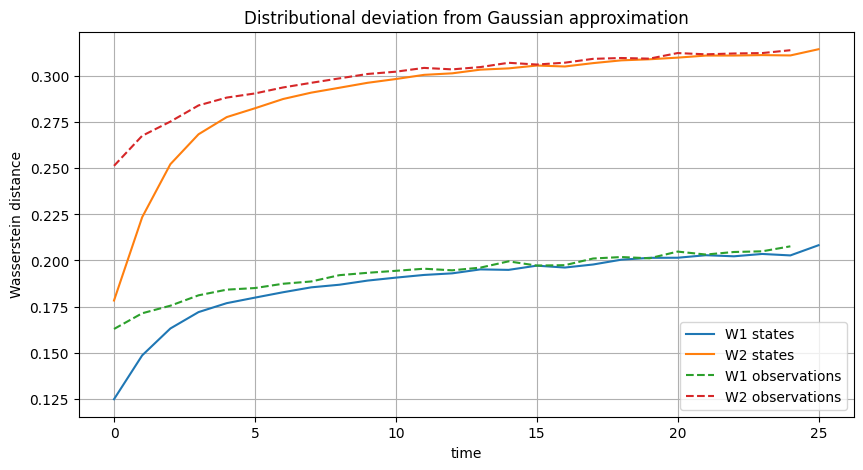

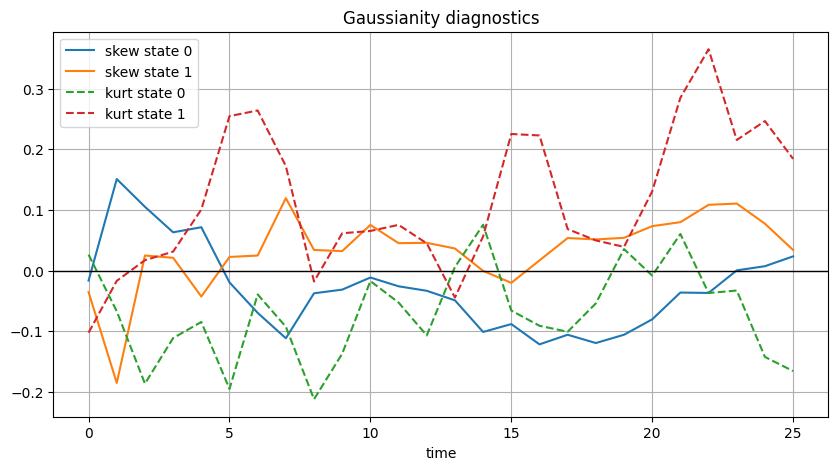

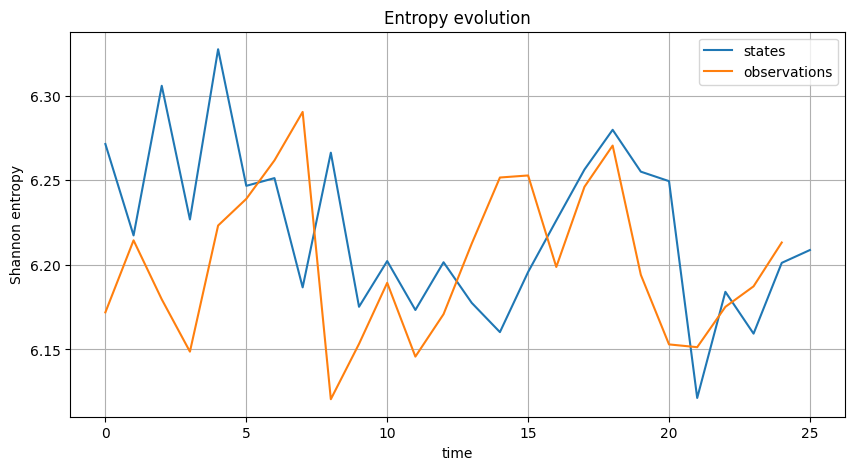

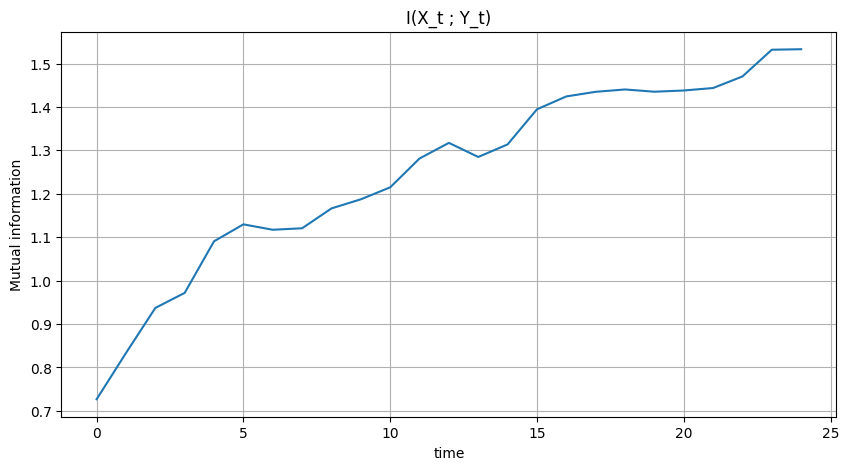

In [62]:
analyzer.plot_wasserstein(results)

analyzer.plot_gaussianity(results)

analyzer.plot_entropy(results)

analyzer.plot_mutual_information(results)

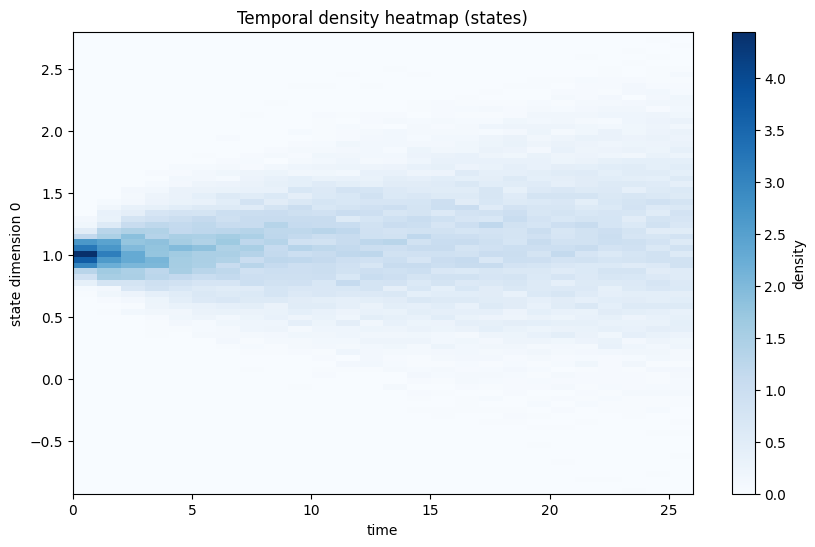

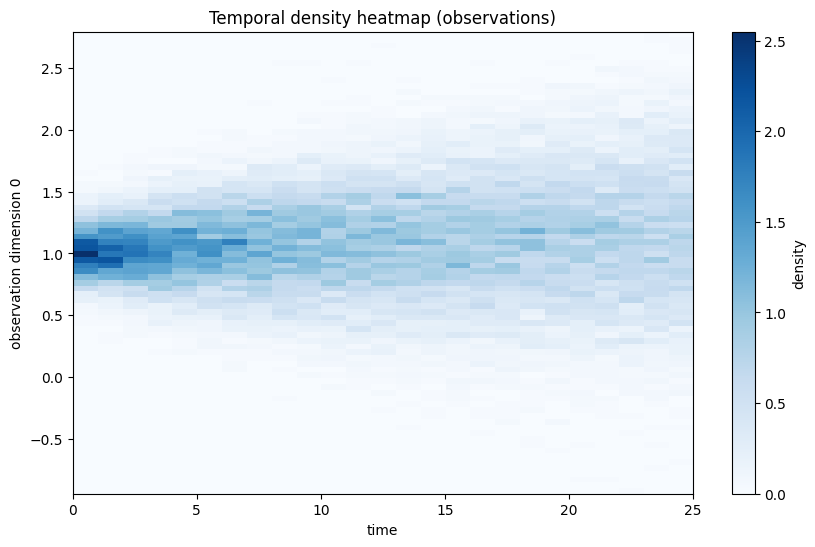

In [63]:
analyzer.plot_density_heatmap(source="states", dim=0)
analyzer.plot_density_heatmap(source="observations", dim=0)

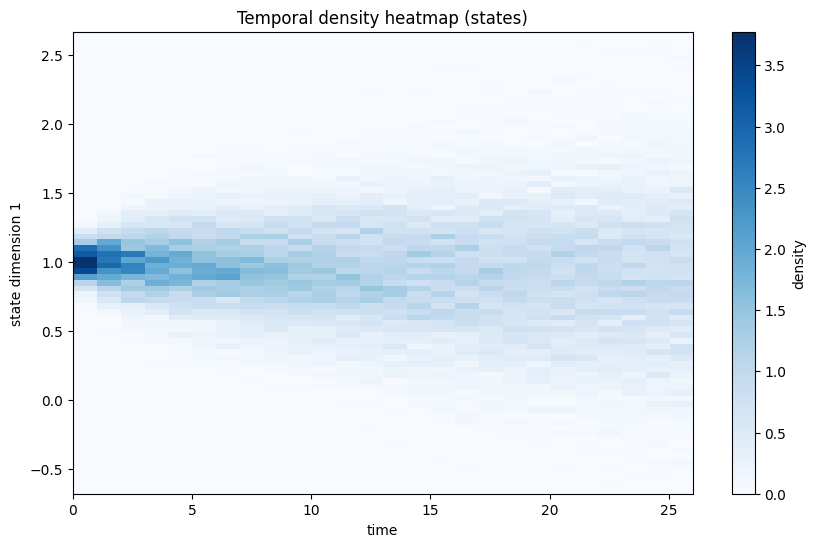

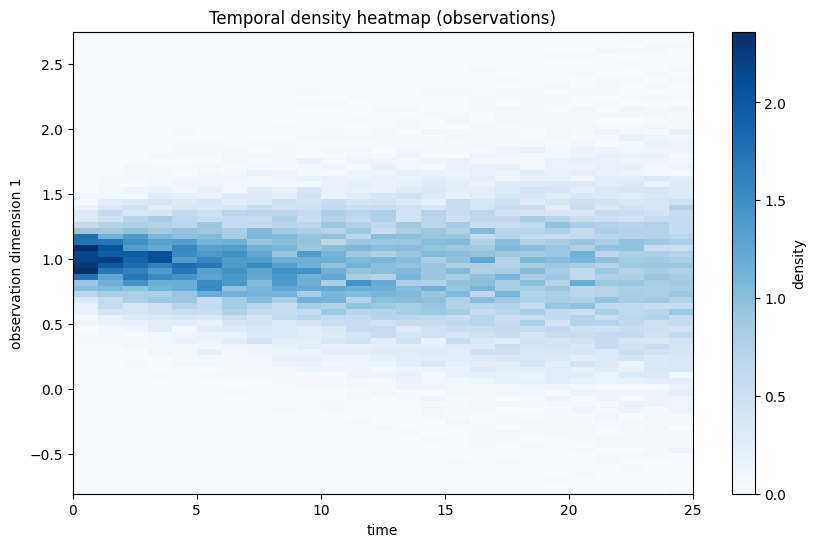

In [64]:
analyzer.plot_density_heatmap(source="states", dim=1)
analyzer.plot_density_heatmap(source="observations", dim=1)

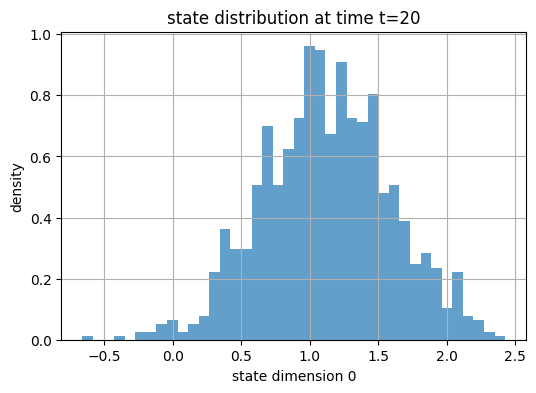

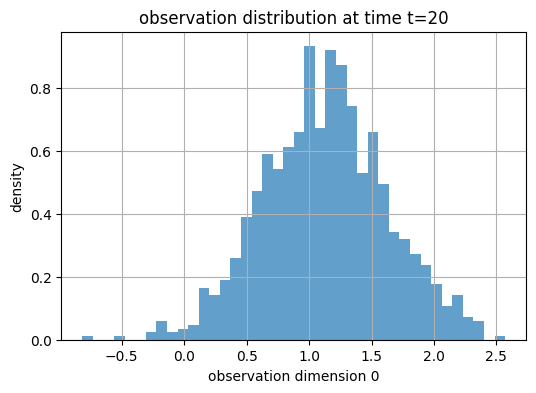

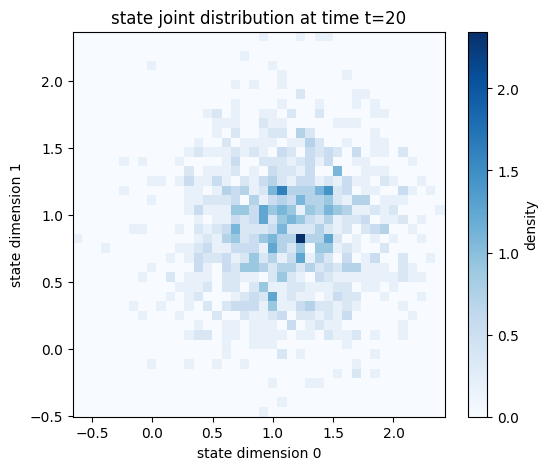

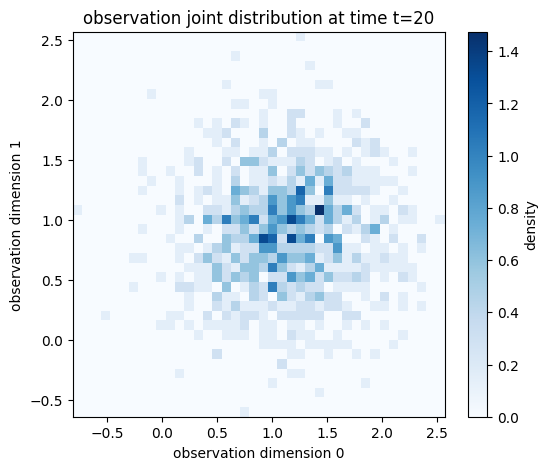

In [65]:
analyzer.plot_snapshot_distribution(
    t=20,
    source="states",
    dims=(0,)
)

analyzer.plot_snapshot_distribution(
    t=20,
    source="observations",
    dims=(0,)
)

analyzer.plot_snapshot_distribution(
    t=20,
    source="states",
    dims=(0,1)
)

analyzer.plot_snapshot_distribution(
    t=20,
    source="observations",
    dims=(0,1)
)

## Experiment 1: Hyperparameter selection

## Experiment 2: Comparison with baseline filters

## Experiment 3: Convergence of bootstrap particle filter from a Gaussian approximation

## Experiment 4: Control error

# Lokta-Volterra non Gaussian state space model